In [101]:
import logging
logging.getLogger("transformers.modeling_utils").setLevel(logging.ERROR)
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt


import umap.umap_ as umap
import hdbscan
from sklearn.metrics import silhouette_score


In [102]:
#Here is data cleaning "hello,cleaning"

In [103]:

DATA_PATH = Path.cwd() / "study_1_ai_data.csv"
assert DATA_PATH.exists(), f"File not found: {DATA_PATH}"

df = pd.read_csv(DATA_PATH, encoding="utf-8", encoding_errors="replace")
print("Shape:", df.shape)
print("Columns:", list(df.columns))

#Find describe_use
use_candidates = [c for c in df.columns if ("describe" in c.lower() and "use" in c.lower())]
USE_COL = use_candidates[0] if len(use_candidates) else "describe_use"
assert USE_COL in df.columns, f"Cannot find text column. Tried USE_COL='{USE_COL}'."
print("USE_COL:", USE_COL)

#Find PID 
pid_candidates = [c for c in df.columns if c.lower() in ["pid","participant_id","prolific_pid","participantid"]]
PID_COL = pid_candidates[0] if len(pid_candidates) else None
print("PID_COL:", PID_COL)

display(df[[USE_COL] + ([PID_COL] if PID_COL else [])].head(10))


Shape: (274, 131)
Columns: ['Unnamed: 0', 'consent', 'attn_check_1', 'attn_check_2', 'pre_assess_task_comparison', 'pre_assess_task_n_expected_ai', 'pre_assess_task_n_expected_noai', 'pre_assess_task_ai_comparison', 'pre_assess_task_n_expected_corr', 'pre_assess_general_comparison', 'pre_assess_general_difficulty_self', 'pre_assess_general_difficulty_others', '4.1', '4.2', '5.1', '5.2', '6.1', '6.2', '7.1', '7.2', '8.1', '8.2', '9.1', '9.2', '10.1', '10.2', '11.1', '11.2', '12.1', '12.2', '13.1', '13.2', '14.1', '14.2', '15.1', '15.2', '16.1', '16.2', '17.1', '17.2', '18.1', '18.2', '19.1', '19.2', '20.1', '20.2', '21.1', '21.2', '22.1', '22.2', '23.1', '23.2', 'describe_use', 'post_assess_task_comparison', 'post_assess_task_n_expected_ai', 'post_assess_task_n_expected_noai', 'post_assess_task_ai_comparison', 'post_assess_task_n_expected_corr', 'post_assess_general_comparison', 'post_assess_general_difficulty_self', 'post_assess_general_difficulty_others', 'snail_f1_v14', 'snail_f1_v17

,describe_use,pid
0,I copied the question and try and made my conc...,664206d50545fd91121b81e2
1,I made the AI aware we are about to solve logi...,65d0863d31c934ef41d1652a
2,i prompted the chat bot to help me solve the c...,6664215e9a4fc14231f523c6
3,"Some specific typing and asking questions, but...",6644c2d3788964cab82269f4
4,I told AI Chatbot what we are about to do,6602a9e51c767d048e510972
5,I mostly copy and paste the questions after an...,5f9115299908a021dfcf4fae
6,I just directly asked it the question and had ...,65e14ceb873675f5079a6874
7,Copy and paste,5fd6f37a0ffc7b67ce2a73a3
8,"I copied and pasted the prompt, and then had t...",65e37d37f4f63b4723f752c0
9,I copied and pasted the prompt to see what the...,6658b337cb2020d6b19f88d9


In [104]:
def clean_text(x):
    if pd.isna(x):
        return ""
    x = str(x).strip()
    x = re.sub(r"\s+", " ", x)
    return x

df["text_clean"] = df[USE_COL].apply(clean_text)
df["n_words"] = df["text_clean"].str.split().map(len)
df["n_chars"] = df["text_clean"].str.len()

display(df[["text_clean","n_words","n_chars"]].head(10))


,text_clean,n_words,n_chars
0,I copied the question and try and made my conc...,14,75
1,I made the AI aware we are about to solve logi...,13,68
2,i prompted the chat bot to help me solve the c...,11,55
3,"Some specific typing and asking questions, but...",12,79
4,I told AI Chatbot what we are about to do,10,41
5,I mostly copy and paste the questions after an...,35,194
6,I just directly asked it the question and had ...,14,67
7,Copy and paste,3,14
8,"I copied and pasted the prompt, and then had t...",41,207
9,I copied and pasted the prompt to see what the...,25,129


In [105]:
BEHAVIOR_PATTERNS = [
    r"\bcopy\b", r"\bpaste\b", r"\bcopy\s*[-]?\s*paste\b",
    r"\bprompt\b", r"\bverbatim\b",

    r"\bdouble\s*check\b", r"\bcheck\b", r"\bverify\b", r"\bconfirm(?:ed|ing|s)?\b",
    r"\bcompare\b", r"\bmatch(?:ed|es|ing)?\b", r"\balign(?:ed|s|ing)?\b",

    r"\bdecid(?:e|ed|ing|sion)\b",
    r"\bdetermin(?:e|ed|ing|ation)\b",
    r"\bcorrect\b", r"\bright\s*answer\b", r"\bbest\s*answer\b",
    
    r"\bexplain\b", r"\bexplanation\b", r"\bclarify\b",
    r"\banaly(?:ze|sis)\b", r"\breason(?:ing)?\b",

    r"\bask(?:ed|ing)?\b",
    r"\bfollow\s*up\b",
    r"\bquestion(?:s)?\b",
    r"\bused\s*it\b",

    r"\bsecond\s*opinion\b", r"\bcross\s*check\b"
]

GENERIC_SENTIMENT_PATTERNS = [
    r"\bhelpful\b", r"\binteresting\b", r"\bfun\b", r"\beasy\b",
    r"\bgood\b", r"\bgreat\b", r"\bimpressive\b", r"\bincredible\b",
    r"\bawesome\b", r"\beducative\b"
]

def has_any(patterns, s: str) -> bool:
    return any(re.search(p, s) for p in patterns)

def is_low_content(s: str) -> bool:
    s = (s or "").strip().lower()
    if not s:
        return True

    has_behavior = has_any(BEHAVIOR_PATTERNS, s)
    has_generic = has_any(GENERIC_SENTIMENT_PATTERNS, s)

    if has_behavior:
        return False

    if len(s) < 12 or len(s.split()) < 3:
        return True

    if has_generic and not has_behavior:
        return True

    return False

df["is_low_content"] = df["text_clean"].apply(is_low_content)
df["used_for_clustering"] = ~df["is_low_content"]

print("Low-content ratio:", df["is_low_content"].mean())
display(df.loc[df["is_low_content"], ["text_clean"]].head(20))


Low-content ratio: 0.01824817518248175


,text_clean
45,it was a good experience
55,sufficiently
76,incredible
85,Th AI Chatbot was very educative
117,pretty good and impressive


In [106]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

mask = df["used_for_clustering"]
texts = df.loc[mask, "text_clean"].tolist()

X = model.encode(texts, convert_to_numpy=True, show_progress_bar=True, normalize_embeddings=True)
print("Embedding shape:", X.shape)

The following layers were not sharded: encoder.layer.*.attention.output.LayerNorm.weight, embeddings.position_embeddings.weight, encoder.layer.*.attention.self.value.weight, encoder.layer.*.attention.output.dense.bias, encoder.layer.*.attention.output.LayerNorm.bias, pooler.dense.bias, embeddings.token_type_embeddings.weight, encoder.layer.*.attention.self.value.bias, encoder.layer.*.output.LayerNorm.bias, encoder.layer.*.attention.self.key.weight, encoder.layer.*.output.dense.bias, encoder.layer.*.output.dense.weight, encoder.layer.*.output.LayerNorm.weight, encoder.layer.*.intermediate.dense.bias, encoder.layer.*.attention.self.key.bias, embeddings.word_embeddings.weight, encoder.layer.*.intermediate.dense.weight, pooler.dense.weight, encoder.layer.*.attention.self.query.weight, embeddings.LayerNorm.weight, encoder.layer.*.attention.self.query.bias, encoder.layer.*.attention.output.dense.weight, embeddings.LayerNorm.bias
Loading weights: 100%|█| 103/103 [00:00<00:00, 1471.76it/s, Mat

Embedding shape: (269, 384)


In [107]:
#UMAP
reducer = umap.UMAP(
    n_neighbors=20,
    n_components=10,
    metric="cosine",
    random_state=42
)
X_red = reducer.fit_transform(X)

print("UMAP shape:", X_red.shape)

#HDBSCAN
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=10,
    min_samples=5,
    metric="euclidean",
    cluster_selection_method="eom"
)

labels = clusterer.fit_predict(X_red)
probs = clusterer.probabilities_
outlier_scores = clusterer.outlier_scores_


df["cluster"] = -999
df["cluster_prob"] = np.nan
df["outlier_score"] = np.nan

df.loc[df["used_for_clustering"], "cluster"] = labels
df.loc[df["used_for_clustering"], "cluster_prob"] = probs
df.loc[df["used_for_clustering"], "outlier_score"] = outlier_scores

# low content in "-2"
df.loc[df["is_low_content"], "cluster"] = -2

print(df["cluster"].value_counts().sort_index())

#silhouette
clusters = sorted(set(labels) - {-1})
if len(clusters) >= 2:
    idx = labels != -1
    print("Silhouette (non-noise):", silhouette_score(X_red[idx], labels[idx]))

/opt/anaconda3/envs/AI_cluster_NLP/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP shape: (269, 10)
cluster
-2     5
-1    48
 0    38
 1    42
 2    28
 3    17
 4    35
 5    23
 6    38
Name: count, dtype: int64
Silhouette (non-noise): 0.5294643640518188


In [108]:
# THE FOUR TAXONOMY: Delegation/Verification/Interaction/Orchestration

In [109]:
CLUSTER_TO_TAXONOMY4 = {
    0: "Delegation",
    1: "Verification",
    2: "Interaction",
    3: "Orchestration",
    4: "Verification",
    5: "Delegation",
    6: "Interaction"
}

In [110]:
df["taxonomy4"] = df["cluster"].map(CLUSTER_TO_TAXONOMY4)

#Label noise and filtered-out data
df.loc[df["cluster"] == -1, "taxonomy4"] = "Noise"
df.loc[df["cluster"] == -2, "taxonomy4"] = "Excluded_low_content"
df.loc[df["cluster"] == -999, "taxonomy4"] = "Missing"

df["taxonomy4"].value_counts()

taxonomy4
Verification            77
Interaction             66
Delegation              61
Noise                   48
Orchestration           17
Excluded_low_content     5
Name: count, dtype: int64

In [111]:
#hierarchical override

In [112]:
#This chunk was optimised with the assistance of GenAI (ChatGPT), incorporating re-guard conditions to prevent misclassification. 



import re
import pandas as pd

USE_COL = "describe_use"

# ============================================================
# 1) Text normalization
# ============================================================
def norm_text(s):
    if pd.isna(s):
        return ""
    s = str(s).lower().strip()
    s = re.sub(r"\s+", " ", s)
    return s

t = df[USE_COL].map(norm_text)

# ============================================================
# 2) Regex patterns
# ============================================================

# -------- Noise / attitude --------
RE_NOISE_ATTITUDE = re.compile(
    r"\b(?:interesting|helpful|useful|good|great|like|enjoy|prefer|"
    r"easier|faster|efficient|convenient|incredible|impressive|educative|"
    r"good\s+experience|remarkable|pretty)\b"
)

NOISE_SINGLETONS = {
    "", "n/a", "na", "none",
    "asking questions", "making questions",
    "copy and paste", "copy pasted", "copied and pasted", "i copied and pasted",
    "i told ai chatbot what we are about to do",
    "sufficiently"
}

# -------- Guards: generic use / passive consumption --------
RE_GUARD_GENERIC_USE = re.compile(
    r"\b(?:used\s+the\s+ai\s+chatbot\s+to\s+solve\s+problems|"
    r"used\s+it\s+to\s+solve|"
    r"used\s+it\s+for\s+an?\s+answer|"
    r"help\s+me\s+answer\s+the\s+questions|"
    r"let\s+it\s+answer\s+it\s+for\s+me|"
    r"let\s+ai\s+figure\s+out\s+the\s+answer|"
    r"interacting\s+with\s+it\s+through\s+text[- ]based\s+conversation|"
    r"type\s+questions,\s*provide\s+information\s+and\s+get\s+answer)\b"
)

RE_GUARD_PASSIVE = re.compile(
    r"\b(?:following\s+the\s+analysis|followed\s+the\s+analysis|"
    r"skimmed\s+the\s+answers|skimmed\s+answers|"
    r"read\s+through\s+its\s+reasoning)\b"
)

RE_GUARD_COPYPASTE_ONLY = re.compile(
    r"^(?:copy|copied|copying)\b.*\b(?:paste|pasted|pasting)\b$|^copy\s+and\s+paste$"
)

# -------- Verification (strict) --------
RE_VERIF_HUMAN_FIRST = re.compile(
    r"\b(?:my\s+answer|i\s+answered|i\s+thought|i\s+decided|"
    r"i\s+decided\s+first|initially|on\s+my\s+own|"
    r"by\s+myself|for\s+myself|i\s+tried\s+to\s+answer|"
    r"solving\s+the\s+problem\s+for\s+myself|"
    r"decisions?\s+i\s+had\s+already\s+made|"
    r"judge(?:d)?\s+my\s+answer)\b"
)


RE_VERIF_COMPARE = re.compile(
    r"\b(?:compare(?:d)?|comparison|checked?\s+against|check\s+.*\s+against|"
    r"double[- ]?check(?:ed)?|double\s+check\s+.*\s+against|"
    r"verified?\s+with|confirm(?:ed|ing)?|"
    r"same\s+conclusion|different\s+conclusion|matched|"
    r"didn'?t\s+match|agree(?:d)?|disagree(?:d)?)\b"
)

# -------- Interaction (explanation-seeking only) --------
RE_INTERACTION = re.compile(
    r"\b(?:why|how|explain|explanation|clarify|clarification|follow[- ]?up|"
    r"asked\s+more\s+questions|open\s+my\s+mind)\b"
)

# -------- Orchestration (task structuring only) --------
RE_ORCHESTRATION = re.compile(
    r"\b(?:break\s+down|divide\s+into|split\s+into|decompose|"
    r"workflow|pipeline|step\s*by\s*step|first\b.*\bthen\b|"
    r"template|rubric|criteria|constraints?|requirements?)\b"
)

RE_GUARD_NOT_ORCH = re.compile(
    r"\b(?:copy|copied|paste|pasted|skimmed|read|reading|analy[sz]ed)\b"
)

# ============================================================
# 3) Boolean masks
# ============================================================

# Guards
guard_generic = t.str.contains(RE_GUARD_GENERIC_USE, na=False)
guard_passive = t.str.contains(RE_GUARD_PASSIVE, na=False)
guard_copypaste_only = t.str.contains(RE_GUARD_COPYPASTE_ONLY, na=False)

# Verification / Interaction / Orchestration
verification_like = (
    t.str.contains(RE_VERIF_HUMAN_FIRST, na=False) &
    t.str.contains(RE_VERIF_COMPARE, na=False)
)

interaction_like = t.str.contains(RE_INTERACTION, na=False)

orchestration_like = (
    t.str.contains(RE_ORCHESTRATION, na=False) &
    ~t.str.contains(RE_GUARD_NOT_ORCH, na=False)
)

# ============================================================
# 4) Noise (refined with anti-noise signals)
#    If ANY evidence of judgment/comparison/explanation -> NOT Noise
# ============================================================

anti_noise_signal = (
    t.str.contains(RE_VERIF_HUMAN_FIRST, na=False) |
    t.str.contains(RE_VERIF_COMPARE, na=False) |
    t.str.contains(RE_INTERACTION, na=False)
)

noise_like = (
    (
        t.isin(NOISE_SINGLETONS) |
        (t.str.len() < 30) |
        t.str.contains(RE_NOISE_ATTITUDE, na=False)
    )
    &
    ~anti_noise_signal
)

# ============================================================
# 5) Apply base taxonomy (strict order)
# ============================================================

df["taxonomy4"] = ""

# A) Noise
df.loc[noise_like, "taxonomy4"] = "Noise"

# B) Verification
df.loc[
    verification_like & (df["taxonomy4"] != "Noise"),
    "taxonomy4"
] = "Verification"

# C) Interaction
df.loc[
    interaction_like & ~df["taxonomy4"].isin(["Noise", "Verification"]),
    "taxonomy4"
] = "Interaction"

# D) Orchestration
df.loc[
    orchestration_like & ~df["taxonomy4"].isin(
        ["Noise", "Verification", "Interaction"]
    ),
    "taxonomy4"
] = "Orchestration"

# E) Delegation (residual)
df.loc[df["taxonomy4"] == "", "taxonomy4"] = "Delegation"

# ============================================================
# 6) Guarded override: force Delegation for generic/passive use
# ============================================================

force_delegation = guard_generic | guard_passive | guard_copypaste_only

df.loc[
    force_delegation
    & (df["taxonomy4"] != "Noise")
    & ~verification_like,    
    "taxonomy4"
] = "Delegation"


# ============================================================
# 7) MINIMAL RESCUE RULES (precision fixes only)
# ============================================================

# A) Rescue Verification: my answer/opinion + explicit comparison
rescue_verification = (
    t.str.contains(
        r"\b(?:my\s+answer|my\s+opinion|what\s+i\s+(?:chose|chosen|picked)|"
        r"the\s+answer\s+i\s+(?:chose|picked)|on\s+my\s+own|"
        r"for\s+myself|by\s+myself|judge(?:d)?\s+my\s+answer)\b",
        na=False
    )
    &
    t.str.contains(
        r"\b(?:compare(?:d)?|comparison|checked?\s+against|verified?\s+with|"
        r"confirm(?:ed|ing)?|same\s+conclusion|different\s+conclusion|matched|"
        r"didn'?t\s+match|agree(?:d)?|disagree(?:d)?)\b",
        na=False
    )
)

df.loc[
    rescue_verification & ~df["taxonomy4"].isin(["Noise", "Verification"]),
    "taxonomy4"
] = "Verification"

# B) Rescue Interaction: doubt/uncertainty + follow-up questioning
rescue_interaction = (
    t.str.contains(r"\b(?:doubt|uncertain|unsure|not\s+sure)\b", na=False)
    &
    t.str.contains(
        r"\b(?:ask(?:ed)?\s+more\s+questions|follow[- ]?up|asked\s+why|asked\s+how|why|how)\b",
        na=False
    )
)

df.loc[
    rescue_interaction & ~df["taxonomy4"].isin(
        ["Noise", "Verification", "Interaction"]
    ),
    "taxonomy4"
] = "Interaction"


In [113]:
df["taxonomy4"].value_counts()

taxonomy4
Delegation       200
Interaction       27
Noise             26
Verification      18
Orchestration      3
Name: count, dtype: int64

In [114]:
df.loc[df["taxonomy4"] == "Noise", USE_COL]

4             I told AI Chatbot what we are about to do 
7                                         Copy and paste
10     I made use of the AI for the questions and it ...
11     I like using the AI Chatbot as it makes work e...
18                                      asking questions
24                                     making questions 
28                                        copy and paste
45                              it was a good experience
51           Very interesting analysis from the Chatbot.
55                                          sufficiently
67     I used it to solve the reasoning questions, I ...
76                                            incredible
85                      Th AI Chatbot was very educative
98     I used it to pretty much answer and analyze ea...
100                                          copy pasted
107    this is very useful for solving any type of pr...
117                           pretty good and impressive
145                            

In [115]:
# Sampling the results within 5 phrases (helpful later to write the findings lol)

def sample_by_taxonomy(df, label, n=5, seed=42):
    sub = df[df["taxonomy4"] == label].copy()
    sub = sub.sort_values(
        ["cluster_prob", "outlier_score"],
        ascending=[False, True]
    )

    if len(sub) <= n:
        return sub

    k = max(n // 2, 5)

    return pd.concat([
        sub.head(k),
        sub.sample(n=n - k, random_state=seed)
    ])

rows = []
for lab in ["Delegation","Verification","Interaction","Orchestration"]:
    if (df["taxonomy4"] == lab).any():
        samp = sample_by_taxonomy(df, lab, n=5, seed=42)
        samp = samp.assign(taxonomy4=lab)
        rows.append(samp[["taxonomy4","cluster","cluster_prob","outlier_score","text_clean"]])

examples_taxonomy = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()
examples_taxonomy.head(30)


,taxonomy4,cluster,cluster_prob,outlier_score,text_clean
0,Delegation,0,1.000000,0.000000,I copied the question and try and made my conc...
1,Delegation,6,1.000000,0.000000,"I copied and pasted the prompt, and then had t..."
2,Delegation,1,1.000000,0.000000,I used the AI Chatbot effectively by giving it...
3,Delegation,6,1.000000,0.000000,By pasting the question and following the anal...
4,Delegation,6,1.000000,0.000000,I copy/pasted the questions and answers and le...
5,Verification,2,1.000000,0.000000,I copied over the questions and answers to get...
6,Verification,4,1.000000,0.000000,Copy and pasted the question and answers. I co...
7,Verification,2,1.000000,0.000000,I would copy and paste each question to the ch...
8,Verification,0,1.000000,0.000000,I copy/pasted each question and tried to see w...
9,Verification,6,1.000000,0.000000,I copied and pasted the prompts from the quest...


In [116]:
#double check/examination

In [117]:
from difflib import SequenceMatcher
import numpy as np

target_text = ("I mainly made a decision before I would copy and paste the questions into the AI Chatbot, and then I would use the argument from the AI to double check the decision I had already made, and revise it if the argument of the AI made sense")

def sim(a, b):
    return SequenceMatcher(None, a, b).ratio()

texts = df[USE_COL].fillna("").astype(str).tolist()
scores = np.array([sim(target_text, x) for x in texts])

topk = 5
idx = np.argsort(scores)[-topk:][::-1]

result = df.loc[idx, [USE_COL, "taxonomy4"]].copy()
result["similarity"] = scores[idx]
result


,describe_use,taxonomy4,similarity
174,I copied the questions into the AI chat-bot th...,Delegation,0.473684
50,I just copy/pasted the questions into the chat...,Delegation,0.460274
236,I would first read the question and try to ans...,Verification,0.446650
179,I copied and pasted the the statements and opt...,Delegation,0.443299
72,i copy and paste the original questions into c...,Delegation,0.435696


In [118]:
from difflib import SequenceMatcher
import numpy as np

target_text = ("I copy/pasted each question and tried to see what answer or conclusion it came to and I them compared it to the answer that I came up with on my own and how well it matched up with the available answers.")

def sim(a, b):
    return SequenceMatcher(None, a, b).ratio()

texts = df[USE_COL].fillna("").astype(str).tolist()
scores = np.array([sim(target_text, x) for x in texts])

topk = 5
idx = np.argsort(scores)[-topk:][::-1]

result = df.loc[idx, [USE_COL, "taxonomy4"]].copy()
result["similarity"] = scores[idx]
result

,describe_use,taxonomy4,similarity
173,I copy/pasted each question and tried to see w...,Verification,0.997543
160,I pasted in the question and answers to see wh...,Interaction,0.528497
175,I entered the initial question then read what ...,Delegation,0.506812
124,Copy and pasted the question and answers. I co...,Verification,0.478114
30,I copied and pasted the prompts and answers an...,Delegation,0.473684


In [119]:
from difflib import SequenceMatcher
import numpy as np

target_text = ("I told AI Chatbot what we are about to do ")

def sim(a, b):
    return SequenceMatcher(None, a, b).ratio()

texts = df[USE_COL].fillna("").astype(str).tolist()
scores = np.array([sim(target_text, x) for x in texts])

topk = 5
idx = np.argsort(scores)[-topk:][::-1]

result = df.loc[idx, [USE_COL, "taxonomy4"]].copy()
result["similarity"] = scores[idx]
result

,describe_use,taxonomy4,similarity
4,I told AI Chatbot what we are about to do,Noise,1.000000
1,I made the AI aware we are about to solve logi...,Delegation,0.527273
104,the AI Chatbot helped me answer the question,Delegation,0.511628
31,I used the AI Chatbot to solve problems.,Delegation,0.487805
93,I used the chatbot to get answers to the quest...,Delegation,0.478261


In [120]:
q = "I would first read the question and try to answer it myself, and then I would double check my answer against chatbot"
mask = df[USE_COL].fillna("").str.contains(q, case=False, na=False)

df.loc[mask, [USE_COL, "taxonomy4", "cluster", "cluster_prob", "outlier_score", "used_for_clustering", "is_low_content"]]


,describe_use,taxonomy4,cluster,cluster_prob,outlier_score,used_for_clustering,is_low_content
236,I would first read the question and try to ans...,Verification,-1,0.0,0.116128,True,False


In [121]:
noise_df = df[df["taxonomy4"] == "Noise"]

if len(noise_df) == 0:
    print("No rows labeled as Noise.")
else:
    noise_df[USE_COL].sample(
        n=min(15, len(noise_df)),
        random_state=42
    )

In [122]:
tax_summary = (
    df["taxonomy4"]
    .value_counts(dropna=False)
    .rename_axis("taxonomy4")
    .reset_index(name="count")
)

In [123]:
tax_summary["proportion"] = tax_summary["count"] / tax_summary["count"].sum()

In [124]:
examples_taxonomy = (
    df
    .loc[df["taxonomy4"].notna(), ["taxonomy4", USE_COL]]
    .groupby("taxonomy4", group_keys=False)
    .apply(lambda x: x.sample(min(5, len(x)), random_state=42))
    .reset_index(drop=True)
)

/var/folders/04/_jpw3kvn5_3b_bmnpd71sgh40000gp/T/ipykernel_23082/817785529.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(5, len(x)), random_state=42))


In [125]:
df.to_csv("study_1_ai_data_with_taxonomy4.csv", index=False)
tax_summary.to_csv("taxonomy4_summary.csv", index=False)
examples_taxonomy.to_csv("taxonomy4_examples.csv", index=False)

print("Saved:")
print("- study_1_ai_data_with_taxonomy4.csv")
print("- taxonomy4_summary.csv")
print("- taxonomy4_examples.csv")

Saved:
- study_1_ai_data_with_taxonomy4.csv
- taxonomy4_summary.csv
- taxonomy4_examples.csv


In [126]:
#Figure 1: Sample distribution across the four taxonomy categories

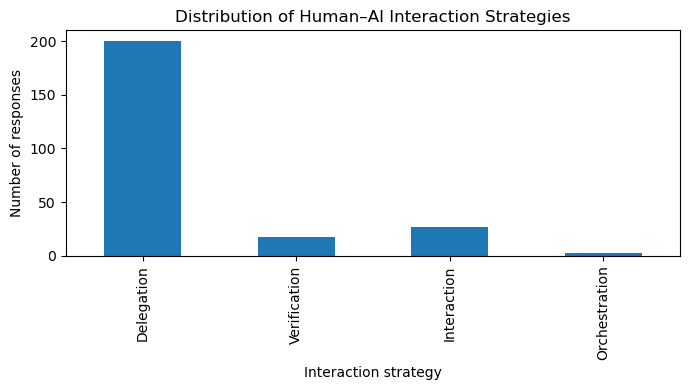

In [127]:


order = ["Delegation", "Verification", "Interaction", "Orchestration"]

counts = (
    df[df["taxonomy4"].isin(order)]
    ["taxonomy4"]
    .value_counts()
    .reindex(order)
)

plt.figure(figsize=(7,4))
counts.plot(kind="bar")
plt.ylabel("Number of responses")
plt.xlabel("Interaction strategy")
plt.title("Distribution of Human–AI Interaction Strategies")
plt.tight_layout()
plt.show()


In [128]:
#Figure 2 : UMAP + taxonomy

In [129]:
mask = df["used_for_clustering"].values

df["umap_x"] = np.nan
df["umap_y"] = np.nan

df.loc[mask, "umap_x"] = X_red[:, 0]
df.loc[mask, "umap_y"] = X_red[:, 1]

df[["umap_x", "umap_y"]].head()


,umap_x,umap_y
0,7.577222,8.079843
1,6.835732,8.752516
2,7.628432,9.160689
3,7.248465,8.181527
4,7.763501,9.248463


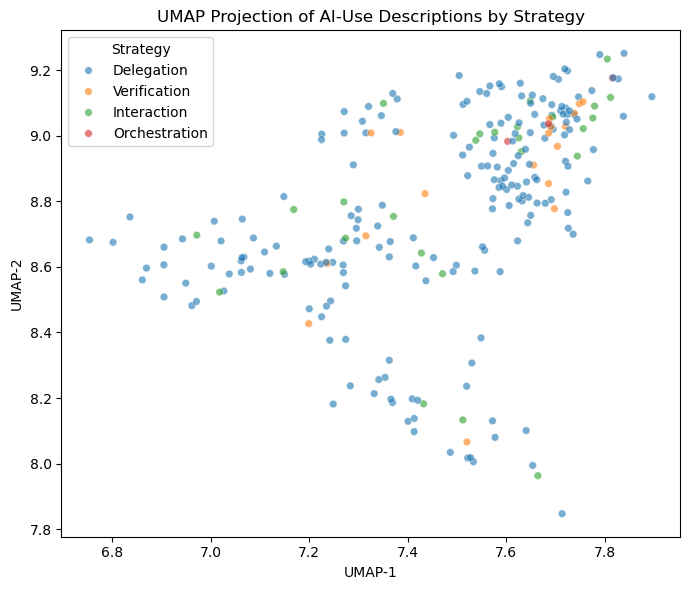

In [130]:
import seaborn as sns
import matplotlib.pyplot as plt

order = ["Delegation", "Verification", "Interaction", "Orchestration"]

plt.figure(figsize=(7,6))
sns.scatterplot(
    data=df[df["taxonomy4"].isin(order)],
    x="umap_x", y="umap_y",
    hue="taxonomy4",
    hue_order=order,
    alpha=0.6,
    s=30
)

plt.title("UMAP Projection of AI-Use Descriptions by Strategy")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.legend(title="Strategy")
plt.tight_layout()
plt.show()


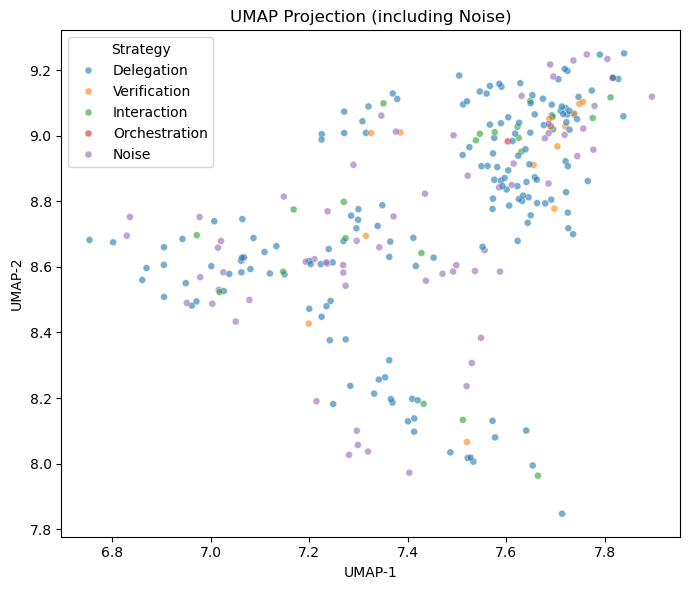

In [138]:
df["taxonomy4_plot"] = df["taxonomy4"].copy()
df.loc[df["cluster"] == -1, "taxonomy4_plot"] = "Noise"

plot_order = ["Delegation", "Verification", "Interaction", "Orchestration", "Noise"]

plt.figure(figsize=(7,6))
sns.scatterplot(
    data=df[df["taxonomy4_plot"].isin(plot_order) & df["used_for_clustering"]],
    x="umap_x", y="umap_y",
    hue="taxonomy4_plot",
    hue_order=plot_order,
    alpha=0.6,
    s=25
)
plt.title("UMAP Projection (including Noise)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.legend(title="Strategy")
plt.tight_layout()
plt.show()


In [142]:
#Figure 3: Differnet effort allocation lead to different performance? （Four Taxonomy × Performance（score））

In [143]:


right_choices = [
    "Soon after the advent of color television, white shirts became less popular as dressy attire for men, and pastel-colored shirts began to sell well.",
    "Federal pay is out of line.",
    "No high jumper entered the meet.",
    "Therefore, if the overweight men between 25 and 50 were to lose weight, their risk of heart disease would be reduced.",
    "Some brilliant mathematicians require calculators for simple multiplication facts.",
    "Women tend to conform to social expectations.",
    "the powerful can often avoid serious criminal sentences",
    "When the dog has fleas, he always scratches. But the dog doesn’t have fleas, so he won’t be scratching.",
    "sign ordinances are rarely, if ever effective",
    "happenstance will be more beneficial to those who are prepared",
    "not doing anything is not an act",
    "Jumbo shrimp may not actually be very big.",
    "the lie detector is sometimes worthless",
    "citing the number of cases in which the lie detector mistook falsehood for truth",
    "The very threat of a lie-detector test has led to a significant number of criminals to confess.",
    "Danish automobiles also leak oil.",
    "disapproving",
    "water conservation",
    "Ten years ago, most letters reached their destination within twenty-four hours.",
    "may or may not pass the course"
]

assert len(right_choices) == 20


In [144]:
def norm_text(x):
    if pd.isna(x):
        return None
    s = str(x).strip().lower()
    s = re.sub(r"\s+", " ", s)
    return s

RIGHT = [norm_text(s) for s in right_choices]

ANSWER_COLS = [
    "4.1", "5.1", "6.1", "7.1", "8.1",
    "9.1", "10.1", "11.1", "12.1", "13.1",
    "14.1", "15.1", "16.1", "17.1", "18.1",
    "19.1", "20.1", "21.1", "22.1", "23.1"
]

assert len(ANSWER_COLS) == 20

item_scores = []
for i, col in enumerate(ANSWER_COLS):
    a = df[col].map(norm_text)
    item_scores.append((a == RIGHT[i]).astype(int))

df["score"] = pd.concat(item_scores, axis=1).sum(axis=1)

print(df["score"].describe())



count    274.000000
mean      12.886861
std        3.110594
min        0.000000
25%       12.000000
50%       14.000000
75%       15.000000
max       17.000000
Name: score, dtype: float64


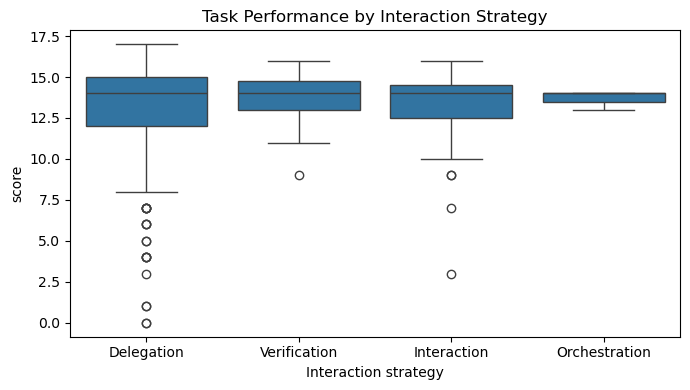

In [146]:
import seaborn as sns
import matplotlib.pyplot as plt

SCORE_COL = "score"
order = ["Delegation", "Verification", "Interaction", "Orchestration"]

plot_df = df[df["taxonomy4"].isin(order)].copy()

plt.figure(figsize=(7,4))
sns.boxplot(
    data=plot_df,
    x="taxonomy4",
    y=SCORE_COL,  
    order=order
)
plt.xlabel("Interaction strategy")
plt.ylabel(SCORE_COL)
plt.title("Task Performance by Interaction Strategy")
plt.tight_layout()
plt.show()


In [147]:
#Table4:  df["bias"] = df["Estimate"] - df["score"]  

In [148]:
# Check with previous RQ1+2 note , if any difference(criteria, result) !

[QC] Invalid post_assess_task_n_expected_ai outside [0, 20]: 3 rows (1.1%)

[Describe] score:
count    271.000000
mean      12.870849
std        3.116551
min        0.000000
25%       12.000000
50%       14.000000
75%       15.000000
max       17.000000
Name: score, dtype: float64

[Describe] post_assess_task_n_expected_ai:
count    271.000000
mean      16.402214
std        3.761973
min        0.000000
25%       15.000000
50%       18.000000
75%       19.000000
max       20.000000
Name: post_assess_task_n_expected_ai, dtype: float64

[Describe] bias & miscalibration:
             bias  miscalibration
count  271.000000      271.000000
mean     3.531365        4.453875
std      4.002538        2.937102
min    -10.000000        0.000000
25%      2.000000        2.000000
50%      4.000000        4.000000
75%      6.000000        6.000000
max     19.000000       19.000000


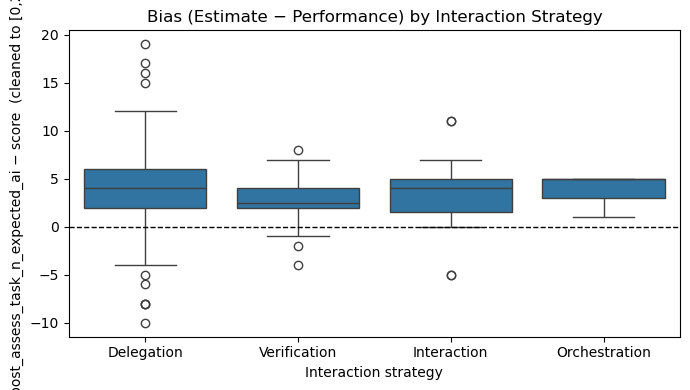

In [149]:
# --- Bias (AI-only; post-task) ---

SCORE_COL = "score"
EST_COL = "post_assess_task_n_expected_ai"
MAX_ITEMS = 20  

assert SCORE_COL in df.columns, f"Cannot find score column: {SCORE_COL}"
assert EST_COL in df.columns, f"Cannot find estimate column: {EST_COL}"

# numeric safety (do not assume types)
df[SCORE_COL] = pd.to_numeric(df[SCORE_COL], errors="coerce")
df[EST_COL] = pd.to_numeric(df[EST_COL], errors="coerce")

#Estimated value
invalid_mask = (~df[EST_COL].between(0, MAX_ITEMS)) & (~df[EST_COL].isna())
n_invalid = int(invalid_mask.sum())
print(f"[QC] Invalid {EST_COL} outside [0, {MAX_ITEMS}]: {n_invalid} rows "
      f"({n_invalid/len(df)*100:.1f}%)")

#exclude invalid estimates for bias analysis only
df_bias = df.loc[~invalid_mask].copy()

#Compute bias
df_bias["bias"] = df_bias[EST_COL] - df_bias[SCORE_COL]
df_bias["miscalibration"] = df_bias["bias"].abs()
df_bias["overconfident"] = (df_bias["bias"] > 0).astype(int)

print("\n[Describe] score:")
print(df_bias[SCORE_COL].describe())

print(f"\n[Describe] {EST_COL}:")
print(df_bias[EST_COL].describe())

print("\n[Describe] bias & miscalibration:")
print(df_bias[["bias", "miscalibration"]].describe())

# Plot
plt.figure(figsize=(7,4))
sns.boxplot(
    data=df_bias[df_bias["taxonomy4"].isin(order)],
    x="taxonomy4",
    y="bias",
    order=order
)
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.xlabel("Interaction strategy")
plt.ylabel(f"{EST_COL} − {SCORE_COL}  (cleaned to [0,{MAX_ITEMS}])")
plt.title("Bias (Estimate − Performance) by Interaction Strategy")
plt.tight_layout()
plt.show()

df["bias_clean"] = np.nan
df.loc[df_bias.index, "bias_clean"] = df_bias["bias"]
df["miscalibration_clean"] = np.nan
df.loc[df_bias.index, "miscalibration_clean"] = df_bias["miscalibration"]


In [150]:
#table5: effort continuum

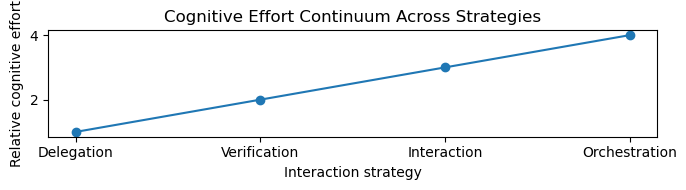

In [151]:
effort_rank = {
    "Delegation": 1,
    "Verification": 2,
    "Interaction": 3,
    "Orchestration": 4
}

df["effort_rank"] = df["taxonomy4"].map(effort_rank)

effort_means = (
    df[df["taxonomy4"].isin(order)]
    .groupby("taxonomy4")["effort_rank"]
    .mean()
    .reindex(order)
)

plt.figure(figsize=(7,2))
plt.plot(order, effort_means, marker="o")
plt.ylabel("Relative cognitive effort")
plt.xlabel("Interaction strategy")
plt.title("Cognitive Effort Continuum Across Strategies")
plt.tight_layout()
plt.show()


In [152]:
# demographic analysis 


[Info] Model N: 271
[Info] taxonomy4 counts:
 taxonomy4
Delegation       199
Interaction       27
Noise             24
Verification      18
Orchestration      3
Name: count, dtype: int64

=== OLS (HC3) on cleaned bias ===
                            OLS Regression Results                            
Dep. Variable:                   bias   R-squared:                       0.059
Model:                            OLS   Adj. R-squared:                  0.016
Method:                 Least Squares   F-statistic:                     1.727
Date:                Fri, 06 Feb 2026   Prob (F-statistic):             0.0614
Time:                        13:32:49   Log-Likelihood:                -751.58
No. Observations:                 271   AIC:                             1529.
Df Residuals:                     258   BIC:                             1576.
Df Model:                          12                                         
Covariance Type:                  HC3                             

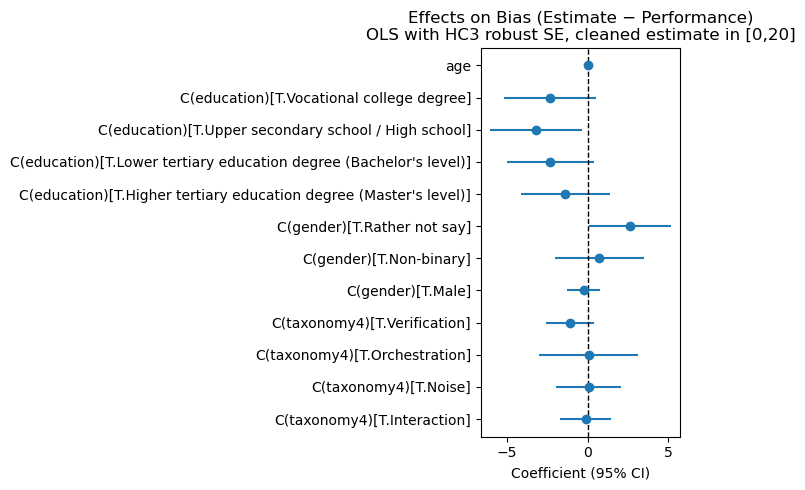


=== OLS (HC3) on miscalibration (|bias|) ===
                            OLS Regression Results                            
Dep. Variable:         miscalibration   R-squared:                       0.065
Model:                            OLS   Adj. R-squared:                  0.021
Method:                 Least Squares   F-statistic:                     2.057
Date:                Fri, 06 Feb 2026   Prob (F-statistic):             0.0202
Time:                        13:32:49   Log-Likelihood:                -666.93
No. Observations:                 271   AIC:                             1360.
Df Residuals:                     258   BIC:                             1407.
Df Model:                          12                                         
Covariance Type:                  HC3                                         
                                                                         coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------

In [153]:

import statsmodels.formula.api as smf

#prepare data fram
required_cols = ["bias", "taxonomy4", "age", "gender", "education"]
missing = [c for c in required_cols if c not in df_bias.columns]
assert len(missing) == 0, f"Missing columns in df_bias: {missing}"

model_df = df_bias.dropna(subset=required_cols).copy()

#Categorical typing
model_df["taxonomy4"] = model_df["taxonomy4"].astype("category")
model_df["gender"] = model_df["gender"].astype("category")
model_df["education"] = model_df["education"].astype("category")

print("\n[Info] Model N:", len(model_df))
print("[Info] taxonomy4 counts:\n", model_df["taxonomy4"].value_counts(dropna=False))

# 2) Main model: bias -  demographics 
m = smf.ols(
    "bias ~ C(taxonomy4) + age + C(gender) + C(education)",
    data=model_df
).fit(cov_type="HC3")

print("\n=== OLS (HC3) on cleaned bias ===")
print(m.summary())

# 3)Show clean, reviewer-friendly coefficient plot (95% CI)
coef = m.params.drop("Intercept")
ci = m.conf_int().loc[coef.index]

plt.figure(figsize=(7, 5))
plt.errorbar(
    coef.values,
    range(len(coef)),
    xerr=[coef.values - ci[0].values, ci[1].values - coef.values],
    fmt="o"
)
plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.yticks(range(len(coef)), coef.index)
plt.xlabel("Coefficient (95% CI)")
plt.title("Effects on Bias (Estimate − Performance)\nOLS with HC3 robust SE, cleaned estimate in [0,20]")
plt.tight_layout()
plt.show()

# 4)Model miscalibration
m2 = smf.ols(
    "miscalibration ~ C(taxonomy4) + age + C(gender) + C(education)",
    data=model_df
).fit(cov_type="HC3")

print("\n=== OLS (HC3) on miscalibration (|bias|) ===")
print(m2.summary())

# 5)Robustness: ElasticNet on the same predictors
from sklearn.model_selection import KFold
from sklearn.linear_model import ElasticNetCV

X = pd.get_dummies(
    model_df[["taxonomy4", "age", "gender", "education"]],
    drop_first=True
)
y = model_df["bias"].astype(float)

enet = ElasticNetCV(
    l1_ratio=[0.2, 0.5, 0.8, 1.0],
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    random_state=42
)
enet.fit(X, y)

coef_enet = pd.Series(enet.coef_, index=X.columns).sort_values()
print("\n=== ElasticNet (Appendix robustness) non-zero coefficients ===")
print(coef_enet[coef_enet != 0])



In [154]:
#table 1：Bias × Strategy

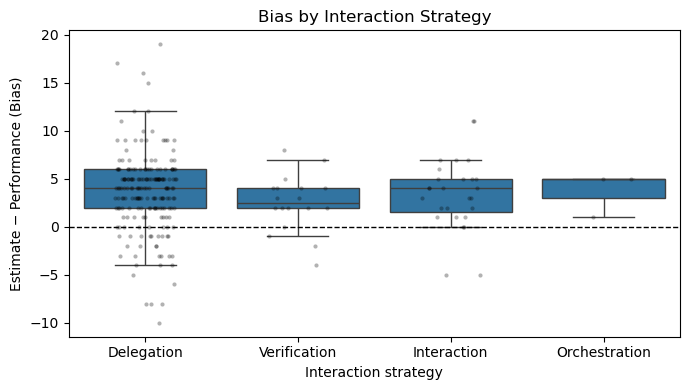

In [155]:
plt.figure(figsize=(7,4))
sns.boxplot(
    data=df_bias[df_bias["taxonomy4"].isin(order)],
    x="taxonomy4",
    y="bias",
    order=order,
    showfliers=False
)
sns.stripplot(
    data=df_bias[df_bias["taxonomy4"].isin(order)],
    x="taxonomy4",
    y="bias",
    order=order,
    color="black",
    alpha=0.3,
    jitter=0.2,
    size=3
)
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.xlabel("Interaction strategy")
plt.ylabel("Estimate − Performance (Bias)")
plt.title("Bias by Interaction Strategy")
plt.tight_layout()
plt.show()


In [156]:
#table 2：Bias distribution

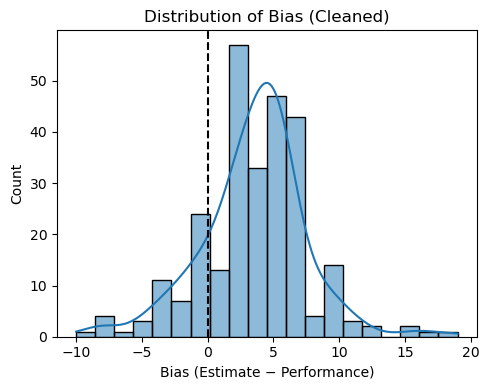

In [157]:
plt.figure(figsize=(5,4))
sns.histplot(df_bias["bias"], bins=20, kde=True)
plt.axvline(0, color="black", linestyle="--")
plt.xlabel("Bias (Estimate − Performance)")
plt.title("Distribution of Bias (Cleaned)")
plt.tight_layout()
plt.show()


In [158]:
#table 3：Calibration  

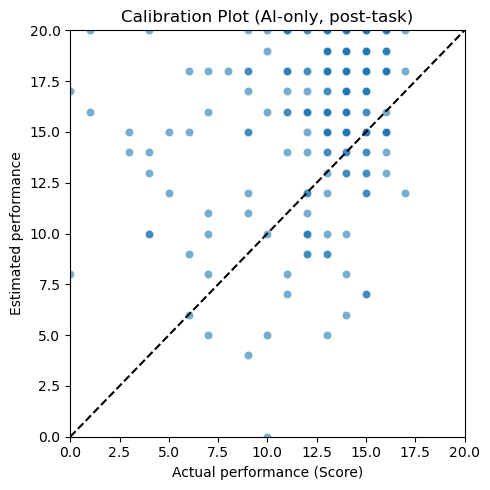

In [159]:
plt.figure(figsize=(5,5))
sns.scatterplot(
    data=df_bias,
    x="score",
    y="post_assess_task_n_expected_ai",
    alpha=0.6
)
plt.plot([0, 20], [0, 20], linestyle="--", color="black")
plt.xlim(0, 20)
plt.ylim(0, 20)
plt.xlabel("Actual performance (Score)")
plt.ylabel("Estimated performance")
plt.title("Calibration Plot (AI-only, post-task)")
plt.tight_layout()
plt.show()


In [160]:
#table 4： calibration of each taxonomy

<Figure size 600x400 with 0 Axes>

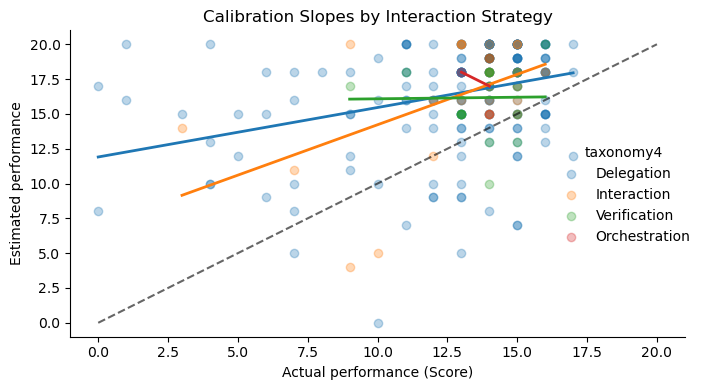

In [161]:
plt.figure(figsize=(6,4))
sns.lmplot(
    data=df_bias[df_bias["taxonomy4"].isin(order)],
    x="score",
    y="post_assess_task_n_expected_ai",
    hue="taxonomy4",
    height=4,
    aspect=1.4,
    scatter_kws={"alpha":0.3},
    line_kws={"linewidth":2},
    ci=None
)
plt.plot([0,20],[0,20],"k--",alpha=0.6)
plt.xlabel("Actual performance (Score)")
plt.ylabel("Estimated performance")
plt.title("Calibration Slopes by Interaction Strategy")
plt.tight_layout()
plt.show()


In [162]:
#table 5：Age × Bias

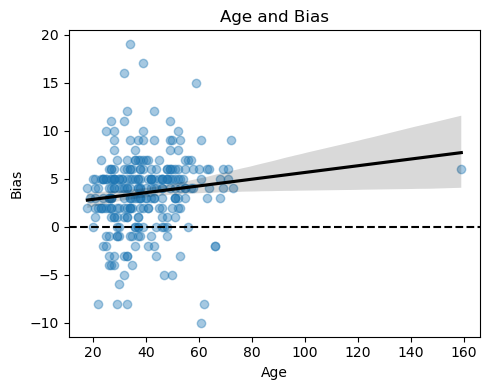

In [163]:
plt.figure(figsize=(5,4))
sns.regplot(
    data=df_bias,
    x="age",
    y="bias",
    scatter_kws={"alpha":0.4},
    line_kws={"color":"black"}
)
plt.axhline(0, color="black", linestyle="--")
plt.xlabel("Age")
plt.ylabel("Bias")
plt.title("Age and Bias")
plt.tight_layout()
plt.show()


In [164]:
#past lives  comparation and will delete later (or maybe not)

In [ ]:
MODEL_NAME = "all-MiniLM-L6-v2"
model = SentenceTransformer(MODEL_NAME)

mask = df["used_for_clustering"]
texts = df.loc[mask, "text_clean"].tolist()

X = model.encode(
    texts,
    convert_to_numpy=True,
    show_progress_bar=True,
    normalize_embeddings=True
)

print("Embedding shape:", X.shape)


In [ ]:
reducer = umap.UMAP(
    n_neighbors=20,
    n_components=10,
    metric="cosine",
    random_state=SEED
)
X_red = reducer.fit_transform(X)

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=10,
    min_samples=5,
    metric="euclidean",
    cluster_selection_method="eom"
)

labels = clusterer.fit_predict(X_red)
probs = clusterer.probabilities_
outlier_scores = clusterer.outlier_scores_


df["cluster"] = -999
df["cluster_prob"] = np.nan
df["outlier_score"] = np.nan

df.loc[mask, "cluster"] = labels
df.loc[mask, "cluster_prob"] = probs
df.loc[mask, "outlier_score"] = outlier_scores

df.loc[df["is_low_content"], "cluster"] = -2

print(df["cluster"].value_counts().sort_index())


clusters = sorted(set(labels) - {-1})
if len(clusters) >= 2:
    idx = labels != -1
    print("Silhouette (non-noise):", silhouette_score(X_red[idx], labels[idx]))


In [ ]:
df_main = df.loc[mask].reset_index(drop=True)
texts_series = df_main["text_clean"].reset_index(drop=True)

def medoid_text(texts_list, Xr):
    D = cosine_distances(Xr, Xr)
    i = int(np.argmin(D.mean(axis=1)))
    return texts_list[i]

def top_terms(texts_list, top_n=12):
    if len(texts_list) < 5:
        return []
    vec = TfidfVectorizer(stop_words="english", ngram_range=(1,2), min_df=2)
    M = vec.fit_transform(texts_list)
    scores = np.asarray(M.mean(axis=0)).ravel()
    terms = np.array(vec.get_feature_names_out())
    top_idx = np.argsort(scores)[::-1][:top_n]
    return list(terms[top_idx])

report = []
for c in sorted(set(labels) - {-1}):
    idx = np.where(labels == c)[0]
    Tc = texts_series.iloc[idx].tolist()
    Xc = X_red[idx]

    tmp = df_main.iloc[idx].copy()
    tmp = tmp.sort_values(["cluster_prob", "outlier_score"], ascending=[True, False])

    report.append({
        "cluster_id": int(c),
        "n": int(len(idx)),
        "medoid": medoid_text(Tc, Xc),
        "top_keywords": ", ".join(top_terms(Tc)),
        "borderline_examples": " || ".join(tmp["text_clean"].head(3).tolist())
    })

cluster_report = pd.DataFrame(report).sort_values("n", ascending=False)
display(cluster_report.head(30))


In [ ]:
#demographic data

In [ ]:
time_cols = [c for c in df.columns if any(k in c.lower() for k in ["time", "duration", "minutes", "seconds", "rt"])]
edu_cols  = [c for c in df.columns if any(k in c.lower() for k in ["education", "edu", "degree"])]
prof_cols = [c for c in df.columns if any(k in c.lower() for k in ["profession", "occupation", "job", "work", "industry"])]

print("time_cols:", time_cols)
print("edu_cols:", edu_cols)
print("prof_cols:", prof_cols)


for c in time_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")


for c in time_cols[:2]: 
    display(df.groupby("cluster")[c].agg(["count","mean","median","std"]).sort_index())


if edu_cols:
    display(pd.crosstab(df["cluster"], df[edu_cols[0]], normalize="index"))
if prof_cols:
    display(pd.crosstab(df["cluster"], df[prof_cols[0]], normalize="index"))


In [ ]:
OUT_DATA = PROJECT_DIR / "outputs" / "study_1_ai_data_with_clusters.csv"
OUT_REPORT = PROJECT_DIR / "outputs" / "cluster_report.csv"
OUT_META = PROJECT_DIR / "outputs" / "run_metadata.json"

df.to_csv(OUT_DATA, index=False)
cluster_report.to_csv(OUT_REPORT, index=False)

meta = {
    "seed": SEED,
    "data_path": str(DATA_PATH),
    "use_col": USE_COL,
    "pid_col": PID_COL,
    "embedding_model": MODEL_NAME,
    "umap": {"n_neighbors": 20, "n_components": 10, "metric": "cosine"},
    "hdbscan": {"min_cluster_size": 10, "min_samples": 5, "metric": "euclidean"},
    "low_content_ratio": float(df["is_low_content"].mean()),
    "n_clusters_excl_noise": int(len(set(labels) - {-1})),
    "noise_ratio": float(np.mean(labels == -1))
}

with open(OUT_META, "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print("Saved:")
print("-", OUT_DATA)
print("-", OUT_REPORT)
print("-", OUT_META)


In [ ]:

plt.figure()
plt.scatter(X_red[:, 0], X_red[:, 1], s=8, c=labels)
plt.title("UMAP (colored by HDBSCAN cluster labels)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")

FIG_PATH = PROJECT_DIR / "figures" / "umap_clusters.png"
plt.savefig(FIG_PATH, bbox_inches="tight")
plt.show()

print("Saved figure:", FIG_PATH)
